In [1]:
pip show accelerate

Name: accelerate
Version: 1.13.0
Summary: Accelerate
Home-page: https://github.com/huggingface/accelerate
Author: The Hugging Face team
Author-email: transformers@huggingface.co
License: Apache
Location: C:\Users\Trixx\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: huggingface_hub, numpy, packaging, psutil, pyyaml, safetensors, torch
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install accelerate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install datasets transformers torch scikit-learn matplotlib pandas

   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 344.6 kB/s  0:00:01
   ---------------------------------------- 0.0/637.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/637.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/637.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/637.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/637.4 kB ? et


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 1. Импорты, seed и устройство
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, pipeline
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# 2. Загрузка датасета и первичный анализ
dataset = load_dataset("emotion")
print(dataset)
print("Метки (классы):", dataset["train"].features["label"].names)

# Примеры
for i in range(5):
    print(f"Text: {dataset['train'][i]['text']}")
    label_id = dataset['train'][i]['label']
    label_name = dataset['train'].features["label"].names[label_id]
    print(f"Label: {label_id} -> {label_name}\n")

# Разбиение уже есть: train, validation, test
print(f"Train size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size: {len(dataset['test'])}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Метки (классы): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Text: i didnt feel humiliated
Label: 0 -> sadness

Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: 0 -> sadness

Text: im grabbing a minute to post i feel greedy wrong
Label: 3 -> anger

Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: 2 -> love

Text: i am feeling grouchy
Label: 3 -> anger

Train size: 16000
Validation size: 2000
Test size: 2000


In [4]:
# 3. Токенизация (базовый разбор на примерах)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_texts = [dataset['train'][i]['text'] for i in range(3)]
for text in sample_texts:
    encoded = tokenizer(text, return_tensors=None)
    print(f"Текст: {text}\n")
    print(f"Токены: {tokenizer.convert_ids_to_tokens(encoded['input_ids'])}")
    print(f"input_ids: {encoded['input_ids']}")
    print(f"attention_mask: {encoded['attention_mask']}")
    print(f"Длина: {len(encoded['input_ids'])}")
    print("-" * 50)

# Пример padding и truncation
encoded_padded = tokenizer(sample_texts, padding=True, truncation=True, max_length=128, return_tensors=None)
print("После padding + truncation (max_length=128):")
for i, ids in enumerate(encoded_padded['input_ids']):
    print(f"Пример {i}: длина = {len(ids)}")

Текст: i didnt feel humiliated

Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
Длина: 7
--------------------------------------------------
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Длина: 23
--------------------------------------------------
Текст: im grabbing a minute to post i feel greedy wrong

Токены: ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel',

In [5]:
# 4. Инференс готовой модели (без fine‑tuning)
# Используем pipeline для анализа тональности (позитив/негатив)
sentiment_pipeline = pipeline("sentiment-analysis", device=0 if torch.cuda.is_available() else -1)

test_examples = [
    "I am so happy today!",
    "I feel very sad and lonely.",
    "I'm angry about what happened.",
    "I love this beautiful weather.",
    "I'm scared of the dark."
]
for ex in test_examples:
    res = sentiment_pipeline(ex)[0]
    print(f"Text: {ex}")
    print(f"Predicted: {res['label']} (confidence: {res['score']:.3f})\n")

# Краткий вывод: готовая модель различает только позитив/негатив, 
# но не умеет распознавать конкретные эмоции (например, 'anger' vs 'fear').
# Поэтому для нашей задачи нужен fine‑tuning.

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text: I am so happy today!
Predicted: POSITIVE (confidence: 1.000)

Text: I feel very sad and lonely.
Predicted: NEGATIVE (confidence: 0.999)

Text: I'm angry about what happened.
Predicted: NEGATIVE (confidence: 0.999)

Text: I love this beautiful weather.
Predicted: POSITIVE (confidence: 1.000)

Text: I'm scared of the dark.
Predicted: NEGATIVE (confidence: 0.986)



In [7]:
# 5. Fine‑tuning для классификации текста
# Подготовка токенизации для всего датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Загружаем модель для классификации (6 классов)
num_labels = len(dataset["train"].features["label"].names)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.to(device)

# Функции для метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

# Аргументы обучения (исправлено: eval_strategy вместо evaluation_strategy)
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",          # ключевое изменение
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# Обучение
trainer.train()

# Оценка на validation
val_metrics = trainer.evaluate()
print("Validation metrics:", val_metrics)

# Финальная оценка на test
test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("Test metrics:", test_metrics)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.612214,0.211651,0.922500,0.896477
2,0.168103,0.156464,0.934500,0.910902
3,0.115351,0.148774,0.937500,0.911599


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


RuntimeError: on_train_begin must be called before on_evaluate

In [8]:
# Обход ошибки
from sklearn.metrics import accuracy_score, f1_score

print("Оценка на validation:")
val_preds = trainer.predict(tokenized_datasets["validation"])
y_val_true = val_preds.label_ids
y_val_pred = np.argmax(val_preds.predictions, axis=-1)
print(f"Validation Accuracy: {accuracy_score(y_val_true, y_val_pred):.4f}")
print(f"Validation F1 macro: {f1_score(y_val_true, y_val_pred, average='macro'):.4f}")

print("\nОценка на test:")
test_preds = trainer.predict(tokenized_datasets["test"])
y_test_true = test_preds.label_ids
y_test_pred = np.argmax(test_preds.predictions, axis=-1)
print(f"Test Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}")
print(f"Test F1 macro: {f1_score(y_test_true, y_test_pred, average='macro'):.4f}")

Оценка на validation:
Validation Accuracy: 0.9375
Validation F1 macro: 0.9116

Оценка на test:


Test Accuracy: 0.9265
Test F1 macro: 0.8781


Test Accuracy: 0.9265
Test F1 (macro): 0.8781


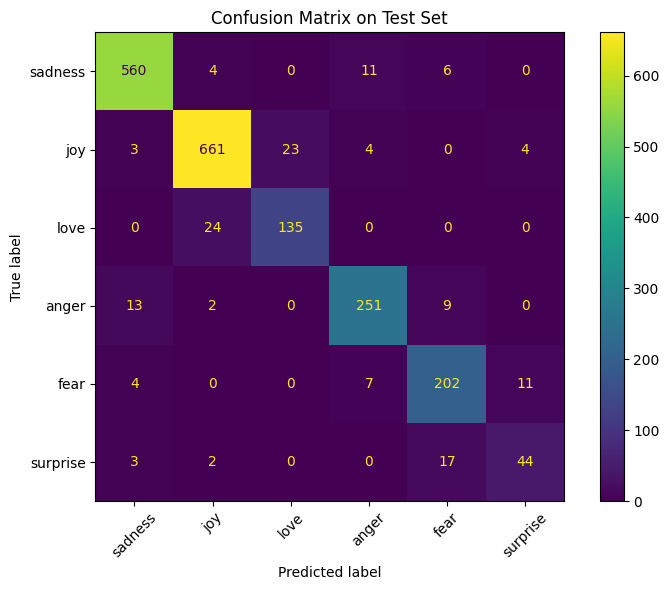

Sample predictions saved to artifacts/sample_predictions.csv
                                                text true_label pred_label  \
0  im feeling rather rotten so im not very ambiti...    sadness    sadness   
1          im updating my blog because i feel shitty    sadness    sadness   
2  i never make her separate from me because i do...    sadness    sadness   
3  i left with my bouquet of red and yellow tulip...        joy        joy   
4    i was feeling a little vain when i did this one    sadness    sadness   
5  i cant walk into a shop anywhere where i do no...       fear       fear   
6   i felt anger when at the end of a telephone call      anger      anger   
7  i explain why i clung to a relationship with a...        joy        joy   
8  i like to have the same breathless feeling as ...        joy        joy   
9  i jest i feel grumpy tired and pre menstrual w...      anger      anger   

   confidence  
0    5.982427  
1    6.078530  
2    5.989505  
3    5.994601  


In [10]:
# 6. Оценка качества и анализ ошибок
# Получаем предсказания на test
import os
os.makedirs("artifacts", exist_ok=True)
test_preds = trainer.predict(tokenized_datasets["test"])
y_true = test_preds.label_ids
y_pred = np.argmax(test_preds.predictions, axis=-1)

# Accuracy и F1 macro уже посчитаны в compute_metrics, но продублируем
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 (macro): {f1:.4f}")

# Матрица ошибок
labels_names = dataset["train"].features["label"].names
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

# Примеры предсказаний (первые 10 из test)
test_texts = dataset["test"]["text"]
sample_indices = list(range(10))
sample_data = []
for idx in sample_indices:
    sample_data.append({
        "text": test_texts[idx],
        "true_label": labels_names[y_true[idx]],
        "pred_label": labels_names[y_pred[idx]],
        "confidence": np.max(test_preds.predictions[idx])  # максимальный логит как proxy уверенности
    })

df_samples = pd.DataFrame(sample_data)
df_samples.to_csv("artifacts/sample_predictions.csv", index=False)
print("Sample predictions saved to artifacts/sample_predictions.csv")
print(df_samples)

# Краткий анализ ошибок
errors = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p]
print(f"\nTotal errors on test: {len(errors)} out of {len(y_true)}")
print("\nПримеры ошибок (первые 5):")
for i in errors[:5]:
    print(f"Text: {test_texts[i]}")
    print(f"True: {labels_names[y_true[i]]} | Pred: {labels_names[y_pred[i]]}")
    print("---")